Mustafa Sefa Soysal // 23050111037

# 2 – Model Training
Initializes U-Net (ResNet34 encoder) and trains for 15 epochs on synthetic data. Saves best model to Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pycocotools segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.0 MB/s eta 0:00:00


## Step 1: Setup – Copy COCO to Local Storage

In [3]:
import os
import shutil

# --- Configuration: UPDATE THESE PATHS ---
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'
local_coco_path = '/content/coco_dataset_local'

# Create the local directory if it doesn't exist
os.makedirs(local_coco_path, exist_ok=True)

print(f"Setting up COCO data in fast local Colab storage ('{local_coco_path}')...")

# --- 1. Copy Annotations ---
drive_annotations_src = os.path.join(drive_coco_path, 'annotations')
local_annotations_dst = os.path.join(local_coco_path, 'annotations')

if os.path.exists(drive_annotations_src) and not os.path.exists(local_annotations_dst):
    print(f"  Copying annotations...")
    try:
        shutil.copytree(drive_annotations_src, local_annotations_dst, dirs_exist_ok=True)
    except OSError as e:
        print(f"\n⚠️ GOOGLE DRIVE BAĞLANTISI KOPTU! (Transport endpoint error)\nLütfen üstteki drive.mount hücresini tekrar çalıştırın veya çalışma zamanını yeniden başlatın.\nHata detayı: {e}")
    print("  Annotations copied successfully.")
elif os.path.exists(local_annotations_dst):
    print("  Annotations already exist in local storage. Skipping copy.")

# --- 2. FAST IMAGE EXTRACTION: Unzip directly to local disk ---
# Instead of copying 100k loose files from Drive (which takes hours),
# we unzip the zip file stored in Drive directly to the fast local SSD.
local_img_dir = os.path.join(local_coco_path, 'images')
os.makedirs(local_img_dir, exist_ok=True)

train_zip = os.path.join(drive_coco_path, 'train2017.zip')
val_zip = os.path.join(drive_coco_path, 'val2017.zip')

print("\n--- Extracting Images to Local Disk ---")
if not os.path.exists(os.path.join(local_img_dir, 'train2017')):
    if os.path.exists(train_zip):
        print("  Unzipping train2017.zip directly to local storage (this is fast)...")
        !unzip -q "{train_zip}" -d "{local_img_dir}"
    else:
        print(f"  Warning: {train_zip} not found in Drive. Ensure it was downloaded in Step 3.")
else:
    print("  train2017 images already exist locally.")

if not os.path.exists(os.path.join(local_img_dir, 'val2017')):
    if os.path.exists(val_zip):
        print("  Unzipping val2017.zip directly to local storage...")
        !unzip -q "{val_zip}" -d "{local_img_dir}"
    else:
        print(f"  Warning: {val_zip} not found in Drive. Ensure it was downloaded in Step 3.")
else:
    print("  val2017 images already exist locally.")

print("\nCOCO data setup for local access complete! Your GPU will no longer be bottlenecked by Drive I/O.")

Setting up COCO data in fast local Colab storage ('/content/coco_dataset_local')...
  Copying annotations...
  Annotations copied successfully.

--- Extracting Images to Local Disk ---
  Unzipping train2017.zip directly to local storage (this is fast)...
  Unzipping val2017.zip directly to local storage...

COCO data setup for local access complete! Your GPU will no longer be bottlenecked by Drive I/O.


## Step 2: Load Annotations and Image Paths

In [4]:
import os
from pycocotools.coco import COCO

# --- Robust Path Resolution ---
local_coco_path = '/content/coco_dataset_local'
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

# Handle nested annotations dynamically (Local first, then Drive)
base_ann_local = os.path.join(local_coco_path, 'annotations')
base_ann_drive = os.path.join(drive_coco_path, 'annotations')

if os.path.exists(os.path.join(base_ann_local, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_ann_local, 'annotations')
elif os.path.exists(os.path.join(base_ann_local, 'instances_train2017.json')):
    annotations_dir = base_ann_local
elif os.path.exists(os.path.join(base_ann_drive, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_ann_drive, 'annotations')
else:
    annotations_dir = base_ann_drive

annotation_filename = 'instances_train2017.json'
annotation_file = os.path.join(annotations_dir, annotation_filename)

print(f"Using annotation directory: {annotations_dir}")

if not os.path.exists(annotation_file):
    print(f"Error: Annotation file not found at {annotation_file}")
else:
    print(f"Successfully found annotation file: {annotation_file}")
    coco = COCO(annotation_file)
    print("\n--- COCO Dataset Information ---")
    cats = coco.loadCats(coco.getCatIds())
    print('COCO categories: %s' % ', '.join([cat['name'] for cat in cats]))
    print(f"Total images: {len(coco.getImgIds())}")

Using annotation directory: /content/coco_dataset_local/annotations/annotations
Successfully found annotation file: /content/coco_dataset_local/annotations/annotations/instances_train2017.json
loading annotations into memory...
Done (t=13.63s)
creating index...
index created!

--- COCO Dataset Information ---
COCO categories: person, bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light, fire hydrant, stop sign, parking meter, bench, bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe, backpack, umbrella, handbag, tie, suitcase, frisbee, skis, snowboard, sports ball, kite, baseball bat, baseball glove, skateboard, surfboard, tennis racket, bottle, wine glass, cup, fork, knife, spoon, bowl, banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake, chair, couch, potted plant, bed, dining table, toilet, tv, laptop, mouse, remote, keyboard, cell phone, microwave, oven, toaster, sink, refrigerator, book, clock, vase, scissors, teddy b

In [5]:
import torch
import torchvision
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor
import os

# Path to the local COCO dataset root
local_coco_path = '/content/coco_dataset_local'

# Because you commented out the image copy step earlier (to save time),
# the images are likely still in your Google Drive.
# We will dynamically check local first, then fallback to Drive.
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

local_img_dir = os.path.join(local_coco_path, 'images', 'train2017')
drive_img_dir = os.path.join(drive_coco_path, 'images', 'train2017')

if os.path.exists(local_img_dir):
    image_root_dir = local_img_dir
    print(f"Using local image directory: {image_root_dir}")
else:
    image_root_dir = drive_img_dir
    print(f"Using Google Drive image directory: {image_root_dir}")

# Handle the nested annotations directory again
base_annotations_dir = os.path.join(local_coco_path, 'annotations')
if os.path.exists(os.path.join(base_annotations_dir, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_annotations_dir, 'annotations')
else:
    annotations_dir = base_annotations_dir

annotation_file_path = os.path.join(annotations_dir, 'instances_train2017.json')

# --- Verify paths before creating dataset ---
if not os.path.exists(image_root_dir):
    print(f"Error: Image root directory not found: {image_root_dir}")
elif not os.path.exists(annotation_file_path):
    print(f"Error: Annotation file not found: {annotation_file_path}")
else:
    print(f"Image root directory found: {image_root_dir}")
    print(f"Annotation file found: {annotation_file_path}")

    # Create the CocoDetection dataset
    dataset = CocoDetection(
        root=image_root_dir,
        annFile=annotation_file_path
    )

    print(f"\nSuccessfully loaded COCO dataset with {len(dataset)} items.")

    # Example: Access an item
    if len(dataset) > 0:
        img, target = dataset[0]
        print(f"\nFirst image type: {type(img)}")
        print(f"First image size: {img.size}")
    else:
        print("Dataset is empty.")

Using local image directory: /content/coco_dataset_local/images/train2017
Image root directory found: /content/coco_dataset_local/images/train2017
Annotation file found: /content/coco_dataset_local/annotations/annotations/instances_train2017.json
loading annotations into memory...
Done (t=11.85s)
creating index...
index created!

Successfully loaded COCO dataset with 118287 items.

First image type: <class 'PIL.Image.Image'>
First image size: (640, 480)


## Step 3: Fixed Split + Seed Function

In [6]:
import os
import hashlib
import copy
import torchvision
from torchvision.datasets import CocoDetection

# --- 1. Deterministic Seed Generation ---
GLOBAL_SEED = 2025

def make_seed(split_name, image_id, global_seed=GLOBAL_SEED):
    key = f"{split_name}_{image_id}_{global_seed}".encode("utf-8")
    return int(hashlib.sha256(key).hexdigest()[:8], 16)

# --- 2. Dynamic Paths (Local first, then Drive) ---
local_coco_path = '/content/coco_dataset_local'
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

def get_img_dir(split):
    local_dir = os.path.join(local_coco_path, 'images', split)
    drive_dir = os.path.join(drive_coco_path, 'images', split)
    return local_dir if os.path.exists(local_dir) else drive_dir

train_img_dir = get_img_dir('train2017')
val_img_dir = get_img_dir('val2017')

base_ann_local = os.path.join(local_coco_path, 'annotations')
base_ann_drive = os.path.join(drive_coco_path, 'annotations')

if os.path.exists(os.path.join(base_ann_local, 'annotations', 'instances_train2017.json')):
    ann_dir = os.path.join(base_ann_local, 'annotations')
elif os.path.exists(os.path.join(base_ann_local, 'instances_train2017.json')):
    ann_dir = base_ann_local
elif os.path.exists(os.path.join(base_ann_drive, 'annotations', 'instances_train2017.json')):
    ann_dir = os.path.join(base_ann_drive, 'annotations')
else:
    ann_dir = base_ann_drive

train_ann_file = os.path.join(ann_dir, 'instances_train2017.json')
val_ann_file = os.path.join(ann_dir, 'instances_val2017.json')

print(f"Using Train Images: {train_img_dir}")
print(f"Using Val Images: {val_img_dir}")
print(f"Using Annotations: {ann_dir}\n")

print("Loading annotations (this may take a moment)...")
try:
    # Initialize full datasets
    train_dataset_full = CocoDetection(root=train_img_dir, annFile=train_ann_file)
    val_dataset_full = CocoDetection(root=val_img_dir, annFile=val_ann_file)

    # --- 3. Sort COCO image IDs in increasing order ---
    train_dataset_full.ids = sorted(train_dataset_full.ids)
    val_dataset_full.ids = sorted(val_dataset_full.ids)

    # --- 4, 5, 6. Create the subsets by slicing the IDs ---
    train_dataset = copy.copy(train_dataset_full)
    train_dataset.ids = train_dataset_full.ids[:5000]

    val_dataset = copy.copy(val_dataset_full)
    val_dataset.ids = val_dataset_full.ids[:1000]

    test_dataset = copy.copy(val_dataset_full)
    test_dataset.ids = val_dataset_full.ids[1000:2000]

    print("\n--- Dataset Splits Created Successfully ---")
    print(f"Training subset size:   {len(train_dataset)} images")
    print(f"Validation subset size: {len(val_dataset)} images")
    print(f"Test subset size:       {len(test_dataset)} images")

except Exception as e:
    print(f"\nAn error occurred: {e}")
    print("Please double check the paths to your images and annotations. If you get an OSError, your Google Drive might be timing out.")
# --- Aliases for compatibility with downstream cells ---
train_coco_subset = train_dataset
val_coco_subset   = val_dataset
test_coco_subset  = test_dataset


Using Train Images: /content/coco_dataset_local/images/train2017
Using Val Images: /content/coco_dataset_local/images/val2017
Using Annotations: /content/coco_dataset_local/annotations/annotations

Loading annotations (this may take a moment)...
loading annotations into memory...
Done (t=11.84s)
creating index...
index created!
loading annotations into memory...
Done (t=0.59s)
creating index...
index created!

--- Dataset Splits Created Successfully ---
Training subset size:   5000 images
Validation subset size: 1000 images
Test subset size:       1000 images


## Step 4: Synthetic Shape Generator

In [7]:
import random
import math
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import torch
import matplotlib.pyplot as plt

def add_synthetic_shapes(base_image, seed=None, prob_positive=0.7):
    """
    Adds synthetic shapes to a PIL image for Semantic Segmentation.
    Returns the modified image and a target dict containing a binary mask.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    is_positive = random.random() < prob_positive
    num_shapes = random.randint(1, 3) if is_positive else 0

    # Convert to RGBA for transparent drawing
    img = base_image.convert("RGBA")
    overlay = Image.new("RGBA", img.size, (255, 255, 255, 0))
    mask_np = np.zeros((img.size[1], img.size[0]), dtype=np.uint8)

    w, h = img.size

    for _ in range(num_shapes):
        shape_type = random.choice(['rectangle', 'ellipse', 'triangle', 'star', 'line'])

        # Difficulty #1: Random opacity & partial transparency
        alpha = random.randint(80, 200)
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255), alpha)

        # Random Size & Location
        sw, sh = random.randint(w//10, w//3), random.randint(h//10, h//3)
        sx = random.randint(0, max(1, w - sw))
        sy = random.randint(0, max(1, h - sh))
        bbox = [sx, sy, sx+sw, sy+sh]

        # Create temporary canvases for rotation
        temp_img = Image.new("RGBA", img.size, (255, 255, 255, 0))
        temp_draw = ImageDraw.Draw(temp_img)
        temp_mask = Image.new("L", img.size, 0)
        temp_mask_draw = ImageDraw.Draw(temp_mask)

        if shape_type == 'rectangle':
            temp_draw.rectangle(bbox, fill=color)
            temp_mask_draw.rectangle(bbox, fill=1)
        elif shape_type == 'ellipse':
            temp_draw.ellipse(bbox, fill=color)
            temp_mask_draw.ellipse(bbox, fill=1)
        elif shape_type == 'triangle':
            p1 = (sx + sw//2, sy)
            p2 = (sx, sy + sh)
            p3 = (sx + sw, sy + sh)
            temp_draw.polygon([p1, p2, p3], fill=color)
            temp_mask_draw.polygon([p1, p2, p3], fill=1)
        elif shape_type == 'star':
            # Draw a 5-pointed star
            cx, cy = sx + sw//2, sy + sh//2
            r_out = min(sw, sh) // 2
            r_in = r_out // 2
            pts = []
            for i in range(10):
                angle = i * math.pi / 5 - math.pi / 2
                r = r_out if i % 2 == 0 else r_in
                pts.append((cx + r * math.cos(angle), cy + r * math.sin(angle)))
            temp_draw.polygon(pts, fill=color)
            temp_mask_draw.polygon(pts, fill=1)
        elif shape_type == 'line':
            # Draw a thick line
            line_width = random.randint(sh//4, sh//2)
            temp_draw.line([(sx, sy), (sx+sw, sy+sh)], fill=color, width=line_width)
            temp_mask_draw.line([(sx, sy), (sx+sw, sy+sh)], fill=1, width=line_width)

        # Required Variation: Rotation
        angle = random.randint(0, 359)
        center = (sx + sw//2, sy + sh//2)
        temp_img = temp_img.rotate(angle, center=center, fillcolor=(0,0,0,0), expand=False, resample=Image.BICUBIC)
        temp_mask = temp_mask.rotate(angle, center=center, fillcolor=0, expand=False, resample=Image.NEAREST)

        # Difficulty #2: Overlapping shapes (Composite the temp layer)
        overlay = Image.alpha_composite(overlay, temp_img)
        mask_np = np.maximum(mask_np, np.array(temp_mask))

    # Composite final overlay onto base image
    img = Image.alpha_composite(img, overlay)

    # Difficulty #3: Random Blur
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

    img = img.convert("RGB")

    # Difficulty #4: Additive Noise
    if random.random() < 0.5:
        img_np_array = np.array(img).astype(np.float32)
        noise = np.random.normal(0, 15, img_np_array.shape) # Gaussian noise
        img_np_array = np.clip(img_np_array + noise, 0, 255).astype(np.uint8)
        img = Image.fromarray(img_np_array)

    target = {
        'mask': torch.tensor(mask_np, dtype=torch.long),
        'is_positive': torch.tensor([1 if is_positive else 0], dtype=torch.int64),
        'num_shapes': torch.tensor([num_shapes], dtype=torch.int64)
    }

    return img, target

print("Synthetic shape generator UPDATED with Stars, Lines, and Rotation!")

Synthetic shape generator UPDATED with Stars, Lines, and Rotation!


## Step 5: PyTorch Dataset Wrapper

In [8]:
import torch
from torch.utils.data import Dataset
import torchvision.tv_tensors as tv_tensors

class SyntheticShapeDataset(Dataset):
    def __init__(self, coco_subset, split_name, transform=None):
        """
        Args:
            coco_subset: The subset of CocoDetection (train, val, or test).
            split_name: 'train', 'val', or 'test'. Used for seed generation.
            transform: Optional v2 transform to be applied symmetrically to image and mask.
        """
        self.coco_subset = coco_subset
        self.split_name = split_name
        self.transform = transform

    def __len__(self):
        return len(self.coco_subset)

    def __getitem__(self, idx):
        # Get original image and image ID from the underlying COCO subset
        img_id = self.coco_subset.ids[idx]
        orig_img, _ = self.coco_subset[idx]

        # 1. Use deterministic seed ONLY for validation and test splits
        seed = None
        if self.split_name in ['val', 'test']:
            seed = make_seed(self.split_name, img_id)

        # 2. Apply the synthetic shape generator
        syn_img, target = add_synthetic_shapes(orig_img, seed=seed)

        # 3. Cleanly add image_id to the target dictionary (Done ONLY here)
        target['image_id'] = torch.tensor([img_id], dtype=torch.int64)

        # 4. Apply v2 Transforms symmetrically (if provided)
        if self.transform:
            # Wrap mask and image in tv_tensors for v2 transformations
            img_tensor = tv_tensors.Image(syn_img)
            mask_tensor = tv_tensors.Mask(target['mask'].unsqueeze(0))

            # Apply spatial transforms
            transformed_img, transformed_mask = self.transform(img_tensor, mask_tensor)

            # Reassign transformed outputs
            syn_img = transformed_img
            target['mask'] = transformed_mask.squeeze(0).long() # Remove channel dim for loss fn

        return syn_img, target

print("Unified Custom Dataset class defined for Option B!")

Unified Custom Dataset class defined for Option B!


## Step 6: U-Net Model Definition

In [9]:
import torch
import segmentation_models_pytorch as smp

# --- NVIDIA A100 / H100 Optimizations ---
if torch.cuda.is_available():
    # Enable cuDNN benchmark for faster convolutions
    torch.backends.cudnn.benchmark = True
    # Enable TF32 for massive speedups on Ampere/Hopper GPUs
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model successfully initialized!")
print(" - Encoder: ResNet34 (Pretrained on ImageNet)")
print(" - Decoder: U-Net Decoder (Trained from scratch)")
print(f" - Device : {device}")
if 'cuda' in device.type:
    print(f" - GPU Name: {torch.cuda.get_device_name(0)}")
    print(f" - TF32 Enabled: {torch.backends.cuda.matmul.allow_tf32}")

# Count parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" - Total params    : {total_params:,}")
print(f" - Trainable params: {trainable_params:,}")

# Dummy test
dummy_input  = torch.randn(2, 3, 256, 256).to(device)
dummy_output = model(dummy_input)
print(f"\nInput shape : {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}  ← Expected [2, 1, 256, 256]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model successfully initialized!
 - Encoder: ResNet34 (Pretrained on ImageNet)
 - Decoder: U-Net Decoder (Trained from scratch)
 - Device : cuda
 - GPU Name: NVIDIA L4
 - TF32 Enabled: True
 - Total params    : 24,436,369
 - Trainable params: 24,436,369

Input shape : torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])  ← Expected [2, 1, 256, 256]


## Step 7: DataLoaders & Transforms

In [10]:
import torchvision.transforms.v2 as v2
import torchvision.tv_tensors as tv_tensors
from torch.utils.data import DataLoader
import os
import torch

# --- Hyperparameters ---
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
WORKERS = min(8, os.cpu_count() or 2)

# --- Training Augmentation & Normalization (v2 Transforms) ---
# v2 transforms allow us to transform images and masks together symmetrically
train_transform = v2.Compose([
    v2.Resize(IMAGE_SIZE),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.3),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = v2.Compose([
    v2.Resize(IMAGE_SIZE),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Applying unified Dataset class and Augmentations...")
if 'train_dataset' in locals():
    train_syn_dataset = SyntheticShapeDataset(train_dataset, "train", transform=train_transform)
    val_syn_dataset = SyntheticShapeDataset(val_dataset, "val", transform=eval_transform)
    test_syn_dataset = SyntheticShapeDataset(test_dataset, "test", transform=eval_transform)

    print("Creating DataLoaders...")
    train_loader = DataLoader(train_syn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS, pin_memory=True)
    val_loader = DataLoader(val_syn_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True)
    test_loader = DataLoader(test_syn_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True)

    print(f"DataLoaders ready! Batch size: {BATCH_SIZE}, Workers: {WORKERS}")
else:
    print("Please run the dataset split cell first to create train_dataset, etc.")

Applying unified Dataset class and Augmentations...
Creating DataLoaders...
DataLoaders ready! Batch size: 64, Workers: 8


## Step 8: Combined Loss (BCE + Dice) & Optimizer

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- Optimization 1: Combined Loss (BCE + Dice) ---
class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce  = nn.BCEWithLogitsLoss()
        self.bce_w  = bce_weight
        self.dice_w = dice_weight

    def dice_loss(self, preds, targets, eps=1e-6):
        preds   = torch.sigmoid(preds)
        inter   = (preds * targets).sum(dim=(2, 3))
        union   = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice    = (2 * inter + eps) / (union + eps)
        return 1 - dice.mean()

    def forward(self, preds, targets):
        return self.bce_w * self.bce(preds, targets) + \
               self.dice_w * self.dice_loss(preds, targets)

criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)

# Optimizer (Added weight decay for better regularization)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# --- LR Scheduler ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

# Metric: Intersection over Union (IoU)
def calculate_iou(preds, labels, threshold=0.0):
    preds = (preds > threshold).float()
    labels = labels.float()

    intersection = (preds * labels).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + labels.sum(dim=(2, 3)) - intersection

    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

print(f"Setup Complete. Combined Loss and Scheduler initialized. Base LR: {LEARNING_RATE}")

Setup Complete. Combined Loss and Scheduler initialized. Base LR: 0.0001


## Step 9: Training Loop (15 Epochs, Mixed Precision)

In [12]:
import time
from torch.amp import GradScaler, autocast

NUM_EPOCHS_OPTIMIZED = 15 # Increased to 15 epochs for better convergence

print(f"--- Starting Optimized Training ---")
print(f"Hardware : {device}")
print(f"Epochs   : {NUM_EPOCHS_OPTIMIZED}")

best_val_iou = 0.0
train_losses, val_losses = [], []
train_ious, val_ious = [], []

# --- Optimization 4: Mixed Precision Training ---
scaler = GradScaler('cuda')
start_time = time.time()

for epoch in range(NUM_EPOCHS_OPTIMIZED):
    # --- Training Phase ---
    model.train()
    epoch_train_loss = 0.0
    epoch_train_iou = 0.0

    for images, targets in train_loader:
        images = images.to(device)
        masks = targets['mask'].to(device).unsqueeze(1).float()

        optimizer.zero_grad()

        # Mixed Precision Context
        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += loss.item() * images.size(0)
        epoch_train_iou += calculate_iou(outputs.float(), masks) * images.size(0)

    epoch_train_loss /= len(train_loader.dataset)
    epoch_train_iou /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    train_ious.append(epoch_train_iou)

    # --- Validation Phase ---
    model.eval()
    epoch_val_loss = 0.0
    epoch_val_iou = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            masks = targets['mask'].to(device).unsqueeze(1).float()

            # Validation is usually done in full precision or mixed, we use mixed for speed
            with autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)

            epoch_val_loss += loss.item() * images.size(0)
            epoch_val_iou += calculate_iou(outputs.float(), masks) * images.size(0)

    epoch_val_loss /= len(val_loader.dataset)
    epoch_val_iou /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_ious.append(epoch_val_iou)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS_OPTIMIZED}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val IoU: {epoch_val_iou:.4f}")

    # Scheduler step based on Val IoU
    scheduler.step(epoch_val_iou)

    # Save Best Model
    if epoch_val_iou > best_val_iou:
        best_val_iou = epoch_val_iou
        torch.save(model.state_dict(), 'best_segmentation_model.pth')
        print("  -> Saved new best model based on Validation IoU!")

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.2f} minutes.")
print("Best model weights saved to 'best_segmentation_model.pth'")

--- Starting Optimized Training ---
Hardware : cuda
Epochs   : 15
Epoch [1/15] | Train Loss: 0.6034 | Val Loss: 0.5174 | Val IoU: 0.5575
  -> Saved new best model based on Validation IoU!
Epoch [2/15] | Train Loss: 0.4770 | Val Loss: 0.4356 | Val IoU: 0.6626
  -> Saved new best model based on Validation IoU!
Epoch [3/15] | Train Loss: 0.4105 | Val Loss: 0.3863 | Val IoU: 0.7375
  -> Saved new best model based on Validation IoU!
Epoch [4/15] | Train Loss: 0.3662 | Val Loss: 0.3424 | Val IoU: 0.7448
  -> Saved new best model based on Validation IoU!
Epoch [5/15] | Train Loss: 0.3318 | Val Loss: 0.3125 | Val IoU: 0.7907
  -> Saved new best model based on Validation IoU!
Epoch [6/15] | Train Loss: 0.3066 | Val Loss: 0.2866 | Val IoU: 0.8290
  -> Saved new best model based on Validation IoU!
Epoch [7/15] | Train Loss: 0.2835 | Val Loss: 0.2712 | Val IoU: 0.8070
Epoch [8/15] | Train Loss: 0.2680 | Val Loss: 0.2568 | Val IoU: 0.8078
Epoch [9/15] | Train Loss: 0.2516 | Val Loss: 0.2471 | Val I

## Step 10: Plot Training History

Saved Training History graph to 'results/figures/training_history.png'


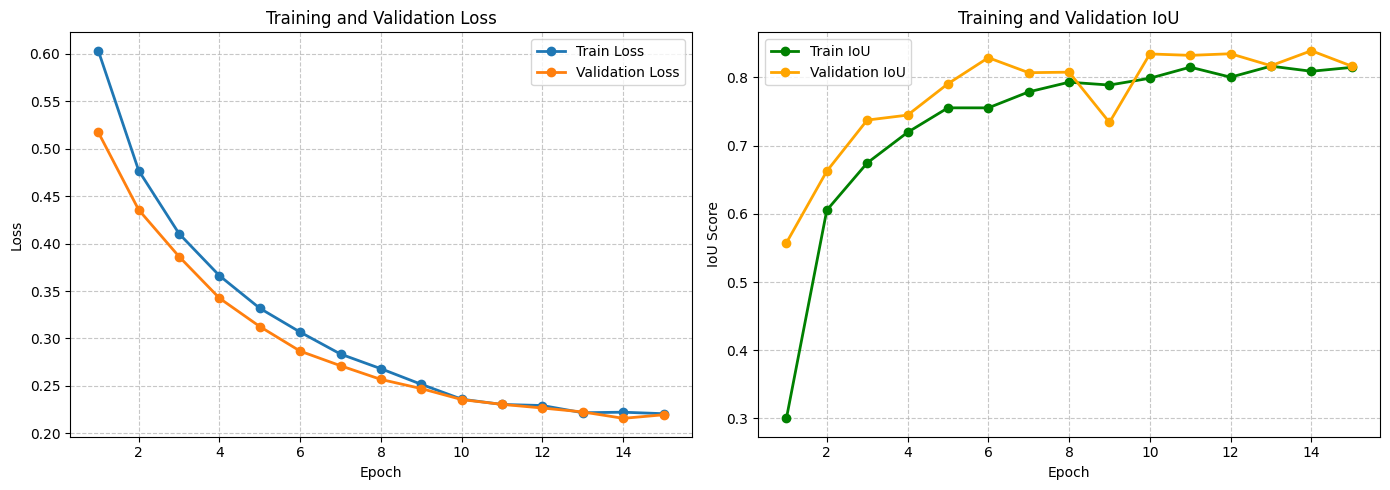

In [13]:
import matplotlib.pyplot as plt
import os

# Ensure the figures directory exists
os.makedirs('results/figures', exist_ok=True)

# Get the number of epochs actually completed
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

# --- Plot 1: Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: IoU ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_ious, label='Train IoU', marker='o', linewidth=2, color='green')
plt.plot(epochs_range, val_ious, label='Validation IoU', marker='o', linewidth=2, color='orange')
plt.title('Training and Validation IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Save the figure to the results folder
plt.savefig('results/figures/training_history.png', dpi=300, bbox_inches='tight')
print("Saved Training History graph to 'results/figures/training_history.png'")

# Display the plot in the notebook
plt.show()

## Step 11: Save Model & Results to Google Drive

In [14]:
import shutil
import os
drive_folder = '/content/drive/MyDrive/Neural_Practice_Exam'
os.makedirs(drive_folder, exist_ok=True)
shutil.copy('best_segmentation_model.pth', os.path.join(drive_folder, 'best_segmentation_model.pth'))
print("Successfully copied best_segmentation_model.pth to Google Drive!")


Successfully copied best_segmentation_model.pth to Google Drive!


In [15]:
import shutil
import os

# Ensure the drive_folder variable is set (from previous cells)
# drive_folder = '/content/drive/MyDrive/Neural_Practice_Exam'

# Copy the training history plot to Google Drive
shutil.copy('results/figures/training_history.png', os.path.join(drive_folder, 'training_history.png'))
print("Successfully copied training_history.png to Google Drive!")

Successfully copied training_history.png to Google Drive!


In [16]:
import json
import os

# Ensure the drive_folder variable is set (from previous cells)
# drive_folder = '/content/drive/MyDrive/Neural_Practice_Exam'

# Prepare data to save
training_metrics = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_ious': train_ious,
    'val_ious': val_ious
}

# Define the path for the metrics file in Google Drive
metrics_filename = 'training_metrics.json'
metrics_drive_path = os.path.join(drive_folder, metrics_filename)

# Save the metrics to a JSON file
with open(metrics_filename, 'w') as f:
    json.dump(training_metrics, f, indent=4)

# Copy the JSON file to Google Drive
shutil.copy(metrics_filename, metrics_drive_path)
print(f"Successfully copied {metrics_filename} to Google Drive!")

Successfully copied training_metrics.json to Google Drive!
